# Football Match Predictor (Latest Models)
Select home and away teams from the dropdowns to get predictions.

In [1]:
# refresh_data = True  → rebuild full_processed_data.csv from data/<league>/ (no retraining)
# refresh_data = False → load existing CSV (fast)
refresh_data = True

import sys, warnings, os, shutil
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.dont_write_bytecode = True

shutil.rmtree('scripts/__pycache__', ignore_errors=True)

from scripts import config, data_loader, utils
from scripts.predict import predict_match
from scripts.utils import safe_odds, confidence_label
import pandas as pd

if refresh_data:
    print('Refreshing processed data from data/ ...')
    _refreshed = data_loader.load_and_process_all_leagues(verbose=True)
    if _refreshed.empty:
        raise RuntimeError(
            'No data loaded. Check that data/<folder> names match keys in '
            'config.LEAGUE_REGISTRY.'
        )
    _refreshed.to_csv(config.PROCESSED_DATA_FILE, index=False)
    _d0, _d1 = _refreshed['Date'].min().date(), _refreshed['Date'].max().date()
    print(f'Saved {len(_refreshed)} matches | {_refreshed["league"].nunique()} '
          f'leagues | {_d0} to {_d1} -> {config.PROCESSED_DATA_FILE}')

print('Loading data...')
historical_data = data_loader.load_processed_data()
team_stats = utils.get_team_stats_table(historical_data)
team_to_league = utils.get_team_to_league_map(historical_data)
all_teams = sorted(utils.get_all_teams(historical_data))
data_leagues = sorted(historical_data['league'].unique())
print(f'Loaded {len(all_teams)} teams | {len(data_leagues)} leagues | '
      f'latest match: {historical_data["Date"].max().date()}')

Refreshing processed data from data/ ...
  Processing Belgian Pro League...
    1844 matches (2020-08-08 to 2026-05-19)
  Processing English Championship...
    3300 matches (2020-09-11 to 2026-04-28)
  Processing English Conference...
    3191 matches (2020-10-03 to 2026-04-25)
  Processing English League One...
    3300 matches (2020-09-12 to 2026-04-28)
  Processing English Premier League...
    2270 matches (2020-09-12 to 2026-05-19)
  Processing Dutch Eredivisie...
    1809 matches (2020-09-12 to 2026-04-26)
  Processing French Ligue 1...
    2057 matches (2020-08-21 to 2026-05-17)
  Processing German Bundesliga...
    1818 matches (2020-09-18 to 2026-05-03)
  Processing German 2. Bundesliga...
    1809 matches (2020-09-18 to 2026-04-26)
  Processing Greek Super League...
    1398 matches (2020-09-11 to 2026-04-26)
  Processing Italian Serie A...
    2270 matches (2020-09-19 to 2026-05-17)
  Processing Portuguese Liga...
    1503 matches (2020-09-18 to 2026-04-29)
  Processing Spa

In [ ]:
from ipywidgets import widgets, VBox, HBox
from IPython.display import display, HTML
from datetime import datetime
import glob

_required = (
    'all_teams', 'predict_match', 'team_stats', 'team_to_league',
    'historical_data', 'confidence_label', 'safe_odds',
)
_missing = [n for n in _required if n not in globals()]
if _missing:
    raise RuntimeError(
        'Run the data-loading cell above first. Missing: ' + ', '.join(_missing)
    )

style = {'description_width': '100px'}

# League dropdown options: ("display name", registry_key). Empty key = All.
_league_options = [('All leagues', '')]
for _k in sorted(historical_data['league'].unique()):
    _disp = config.LEAGUE_REGISTRY.get(_k, {}).get('display_name', _k)
    _league_options.append((_disp, _k))

league_dropdown = widgets.Dropdown(
    options=_league_options, value='', description='League:',
    style=style, layout={'width': '400px'})

home_dropdown = widgets.Dropdown(
    options=all_teams, description='Home Team:',
    style=style, layout={'width': '400px'})
away_dropdown = widgets.Dropdown(
    options=all_teams, description='Away Team:',
    style=style, layout={'width': '400px'},
    value=all_teams[1] if len(all_teams) > 1 else None)


def _teams_in_league(league_key):
    if not league_key:
        return all_teams
    mask = historical_data['league'] == league_key
    teams = pd.concat([
        historical_data.loc[mask, 'HomeTeam'],
        historical_data.loc[mask, 'AwayTeam'],
    ]).dropna().unique()
    return sorted(teams)


def _on_league_change(change):
    if change['name'] != 'value':
        return
    teams = _teams_in_league(change['new'])
    if not teams:
        return
    home_dropdown.options = teams
    away_dropdown.options = teams
    home_dropdown.value = teams[0]
    away_dropdown.value = teams[1] if len(teams) > 1 else teams[0]


league_dropdown.observe(_on_league_change, names='value')

_BADGE = {'Strong': '#27ae60', 'Moderate': '#f39c12', 'Low': '#e74c3c'}


def _freshness_banner(home_team):
    latest = historical_data['Date'].max()
    latest_str = latest.date().isoformat() if pd.notna(latest) else 'unknown'
    tier1 = os.path.join(os.path.dirname(config.MODELS_TIER1_DIR), 'tier1')
    files = glob.glob(os.path.join(tier1, '*.joblib'))
    if files:
        newest_mtime = max(os.path.getmtime(f) for f in files)
        model_str = datetime.fromtimestamp(newest_mtime).date().isoformat()
    else:
        model_str = 'unknown'
    home_league = team_to_league.get(home_team, '')
    ch_note = ''
    if home_league == 'CH':
        xgb = os.path.exists(os.path.join(tier1, 'model_1x2_CH.joblib'))
        lgbm = os.path.exists(os.path.join(tier1, 'model_1x2_CH_lgbm.joblib'))
        if xgb and not lgbm:
            ch_note = (" &nbsp;|&nbsp; <span style='color:#e67e22;'>"
                       "Swiss: XGB-only (LGBM pending)</span>")
    return (f"<p style='margin:0 0 6px;font-size:12px;color:#7f8c8d;'>"
            f"Latest match: <b>{latest_str}</b> &nbsp;|&nbsp; "
            f"Models updated: <b>{model_str}</b>{ch_note}</p>")

def _conf_badge(prob):
    label = confidence_label(prob)
    col = _BADGE[label]
    return (f"<span style='margin-left:8px;padding:2px 8px;border-radius:4px;"
            f"background:{col};color:#fff;font-size:12px;'>{label} ({prob:.0%})</span>")

def _market_table(title, rows, badge_prob=None):
    badge = _conf_badge(badge_prob) if badge_prob else ''
    h = f"<h4 style='margin:10px 0 5px;'>{title}{badge}</h4>"
    h += "<table style='font-size:15px;border-collapse:collapse;'>"
    for i, (label, prob) in enumerate(rows):
        bg = 'background:#ecf0f1;' if i % 2 == 0 else ''
        o = f'{safe_odds(prob):.2f}' if prob > 0.001 else '-'
        h += (f"<tr style='{bg}'>"
              f"<td style='padding:8px 14px;border:1px solid #bdc3c7;'><b>{label}</b></td>"
              f"<td style='padding:8px 14px;border:1px solid #bdc3c7;'>{prob:.1%}</td>"
              f"<td style='padding:8px 14px;border:1px solid #bdc3c7;'>@ {o}</td></tr>")
    return h + '</table>'

def _goals_ladder_html(pred):
    ou15, ou25, ou35 = pred.get('ou15'), pred.get('ou25'), pred.get('ou35')
    if not (ou15 and ou25 and ou35):
        return ''
    p15 = ou15['over']
    p25 = min(ou25['over'], p15)
    p35 = min(ou35['over'], p25)
    bands = [
        ('0-1 goals', 1 - p15,  '#3498db'),
        ('2 goals',   p15 - p25, '#2ecc71'),
        ('3 goals',   p25 - p35, '#f1c40f'),
        ('4+ goals',  p35,       '#e74c3c'),
    ]
    h = "<h4 style='margin:10px 0 5px;'>Goals Ladder</h4>"
    h += "<div style='width:100%;max-width:420px;'>"
    for label, frac, col in bands:
        pct = max(frac * 100, 0)
        h += (f"<div style='display:flex;align-items:center;margin:2px 0;'>"
              f"<span style='width:80px;font-size:13px;'>{label}</span>"
              f"<div style='flex:1;background:#ecf0f1;border-radius:4px;height:22px;'>"
              f"<div style='width:{pct:.1f}%;background:{col};height:100%;"
              f"border-radius:4px;min-width:2px;'></div></div>"
              f"<span style='width:50px;text-align:right;font-size:13px;margin-left:4px;'>"
              f"{frac:.0%}</span></div>")
    h += '</div>'
    return h

def _render_prediction(pred):
    h = ""
    if '1x2' in pred:
        p = pred['1x2']
        top_p = max(p['home'], p['draw'], p['away'])
        h += _market_table('1X2', [
            ('Home', p['home']), ('Draw', p['draw']), ('Away', p['away'])
        ], badge_prob=top_p)
        _dc1x, _dcx2, _dc12 = (p['home'] + p['draw'],
                               p['draw'] + p['away'],
                               p['home'] + p['away'])
        h += (f"<p style='margin:2px 0 8px;font-size:13px;color:#7f8c8d;'>"
              f"Double Chance: 1X {_dc1x:.0%} @ {safe_odds(_dc1x):.2f} "
              f"&nbsp;|&nbsp; X2 {_dcx2:.0%} @ {safe_odds(_dcx2):.2f} "
              f"&nbsp;|&nbsp; 12 {_dc12:.0%} @ {safe_odds(_dc12):.2f}</p>")
    h += _goals_ladder_html(pred)
    if 'ou25' in pred:
        o = pred['ou25']
        top_p = max(o['over'], o['under'])
        h += _market_table('Over/Under 2.5', [
            ('Over 2.5', o['over']), ('Under 2.5', o['under'])
        ], badge_prob=top_p)
    if 'ou15' in pred:
        o = pred['ou15']
        h += _market_table('Over/Under 1.5', [
            ('Over 1.5', o['over']), ('Under 1.5', o['under'])])
    if 'ou35' in pred:
        o = pred['ou35']
        h += _market_table('Over/Under 3.5', [
            ('Over 3.5', o['over']), ('Under 3.5', o['under'])])
    if 'btts' in pred:
        b = pred['btts']
        top_p = max(b['yes'], b['no'])
        h += _market_table('Both Teams To Score', [
            ('Yes', b['yes']), ('No', b['no'])
        ], badge_prob=top_p)
    if 'ht1x2' in pred:
        p = pred['ht1x2']
        h += _market_table('Half-Time Result', [
            ('Home', p['home']), ('Draw', p['draw']), ('Away', p['away'])])
    if 'htou05' in pred:
        o = pred['htou05']
        h += _market_table('HT Over/Under 0.5', [
            ('Over 0.5', o['over']), ('Under 0.5', o['under'])])
    if 'xg' in pred:
        h += f"<h4 style='margin:10px 0 5px;'>Expected Goals</h4>"
        h += f"<p style='font-size:20px;'><b>{pred['xg']['home']:.2f}</b> - <b>{pred['xg']['away']:.2f}</b></p>"
        if 'top_scores' in pred:
            h += ("<h4 style='margin:10px 0 5px;'>Most Likely Scores</h4>"
                  "<table style='font-size:14px;border-collapse:collapse;'>")
            for sc, pr in pred['top_scores'][:6]:
                h += (f"<tr><td style='padding:4px 12px;border:1px solid #bdc3c7;'>{sc}</td>"
                      f"<td style='padding:4px 12px;border:1px solid #bdc3c7;'>{pr:.1%}</td></tr>")
            h += '</table>'
        if 'poisson' in pred:
            ps = pred['poisson']
            h += ("<p style='margin:6px 0;font-size:13px;color:#7f8c8d;'>"
                  f"<b>Poisson cross-check:</b> O2.5 {ps['over25']:.0%} / U2.5 {ps['under25']:.0%}"
                  f" &nbsp;|&nbsp; BTTS Yes {ps['btts_yes']:.0%} / No {ps['btts_no']:.0%}</p>")
    return h

def update_prediction(home_team, away_team):
    """Called by interactive_output once per change (avoids duplicate observers)."""
    if home_team == away_team:
        print('Please select different teams')
        return
    try:
        pred = predict_match(home_team, away_team, team_stats,
                             team_to_league, historical_data)
        disp = config.LEAGUE_REGISTRY.get(pred['league'], {}).get(
            'display_name', pred['league'])
        html = _freshness_banner(home_team)
        html += (f"<h2 style='color:#2c3e50;'>{home_team} vs {away_team}</h2>"
                 f"<p><b>League:</b> {disp}</p>")
        html += _render_prediction(pred)
        display(HTML(html))
    except Exception:
        import traceback
        traceback.print_exc()

# interactive_output clears its Output and runs the callback once per widget change
# (using observe() on both dropdowns + calling make_prediction() once often produced
# 2–3 identical renders on load or after re-running the cell).
pred_out = widgets.interactive_output(
    update_prediction,
    {'home_team': home_dropdown, 'away_team': away_dropdown},
)
ui = VBox([league_dropdown, home_dropdown, away_dropdown, pred_out])
display(ui)

---
## Analytics

The cells below evaluate the **saved** ensemble (XGB + LGBM) on the most recent slice of
`historical_data`. Nothing retrains. Edit `EVAL_WINDOW_DAYS` to change the window.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, mean_absolute_error

from scripts.predict import _load_ensemble, _ensemble_proba, _ensemble_predict

EVAL_WINDOW_DAYS = 90
MIN_LEAGUE_ROWS = 30

_eval_cutoff = historical_data['Date'].max() - pd.Timedelta(days=EVAL_WINDOW_DAYS)
eval_data = historical_data[historical_data['Date'] >= _eval_cutoff].copy()
print(f'Eval window: last {EVAL_WINDOW_DAYS} days '
      f'({_eval_cutoff.date()} to {historical_data["Date"].max().date()}) '
      f'| {len(eval_data)} matches')


def _league_slice(league, cols_required):
    lt = eval_data[eval_data['league'] == league]
    feats = config.get_features_for_league(league)
    lt = lt.dropna(subset=feats + cols_required)
    return lt, feats


def _display_name(key):
    return config.LEAGUE_REGISTRY.get(key, {}).get('display_name', key)


def _html_table(headers, rows, pooled=None):
    h = "<table style='font-size:13px;border-collapse:collapse;margin:8px 0;'>"
    h += "<tr>" + ''.join(
        f"<th style='padding:6px 10px;border:1px solid #bdc3c7;"
        f"background:#34495e;color:#fff;text-align:left;'>{c}</th>"
        for c in headers) + "</tr>"
    for i, r in enumerate(rows):
        bg = '#ecf0f1' if i % 2 == 0 else '#ffffff'
        h += (f"<tr>" + ''.join(
            f"<td style='padding:6px 10px;border:1px solid #bdc3c7;"
            f"background:{bg};color:#2c3e50;'>{c}</td>"
            for c in r) + "</tr>")
    if pooled is not None:
        h += ("<tr>" + ''.join(
            f"<td style='padding:6px 10px;border:1px solid #bdc3c7;"
            f"background:#2c3e50;color:#fff;font-weight:bold;'>{c}</td>"
            for c in pooled) + "</tr>")
    return h + "</table>"

Eval window: last 90 days (2026-01-29 to 2026-04-29) | 2624 matches


### 1X2 top-2 accuracy

For every match we take the two most probable outcomes from the ensemble and check whether the
actual FTR is one of them. Random guessing covers 2 of 3 outcomes = 66.7%; a well-calibrated
model will beat that meaningfully.

In [8]:
rows_1x2 = []
pooled_top2_hits = 0
pooled_top1_hits = 0
pooled_n = 0

for league in sorted(eval_data['league'].unique()):
    lt, feats = _league_slice(league, ['result_label', 'FTR'])
    if len(lt) < MIN_LEAGUE_ROWS:
        continue
    models = _load_ensemble('1x2', league)
    if not models:
        continue
    try:
        probs = _ensemble_proba(models, lt[feats])
    except Exception:
        continue
    y = lt['result_label'].astype(int).values
    top2 = np.argsort(probs, axis=1)[:, ::-1][:, :2]
    top1 = np.argmax(probs, axis=1)
    n = len(y)
    k_top2 = int(sum(y[i] in top2[i] for i in range(n)))
    k_top1 = int((top1 == y).sum())
    rows_1x2.append((
        _display_name(league),
        f'{k_top1/n:.1%}',
        f'{k_top2/n:.1%}',
        n,
    ))
    pooled_top2_hits += k_top2
    pooled_top1_hits += k_top1
    pooled_n += n

rows_1x2.sort(key=lambda r: r[2], reverse=True)
pooled = None
if pooled_n:
    pooled = (
        'POOLED',
        f'{pooled_top1_hits/pooled_n:.1%}',
        f'{pooled_top2_hits/pooled_n:.1%}',
        pooled_n,
    )
display(HTML('<h4>1X2 accuracy (saved ensemble, recent window)</h4>' +
             _html_table(['League', 'Top-1 acc', 'Top-2 acc', 'N'], rows_1x2, pooled)))

League,Top-1 acc,Top-2 acc,N
German Bundesliga,59.6%,83.5%,109
Turkish Super Lig,51.9%,81.5%,108
Belgian Pro League,53.9%,81.4%,102
Brazilian Serie A,52.5%,80.8%,120
Spanish La Liga,50.4%,80.2%,121
Argentine Liga,44.0%,78.5%,200
Chinese Super League,53.1%,78.1%,64
Italian Serie A,55.8%,77.5%,120
English Championship,48.2%,76.6%,197
Spanish Segunda,53.9%,76.6%,154


### Market accuracy (O/U 1.5, O/U 2.5, O/U 3.5, BTTS)

Binary markets, same eval window. `LogLoss` lower is better; `Brier` lower is better (probability-aware);
`Acc` is straight hit rate at the 0.5 threshold.

In [9]:
_BINARY_MARKETS = [
    ('ou15', 'over_1_5', 'O/U 1.5'),
    ('ou25', 'over_2_5', 'O/U 2.5'),
    ('ou35', 'over_3_5', 'O/U 3.5'),
    ('btts', 'btts',     'BTTS'),
]

for market, target, label in _BINARY_MARKETS:
    rows = []
    pooled = {'acc': 0, 'll': 0.0, 'br': 0.0, 'n': 0}
    for league in sorted(eval_data['league'].unique()):
        lt, feats = _league_slice(league, [target])
        if len(lt) < MIN_LEAGUE_ROWS:
            continue
        models = _load_ensemble(market, league)
        if not models:
            continue
        try:
            probs = _ensemble_proba(models, lt[feats])
        except Exception:
            continue
        y = lt[target].astype(int).values
        p_pos = probs[:, 1] if probs.shape[1] == 2 else probs[:, -1]
        pred = (p_pos >= 0.5).astype(int)
        try:
            ll = log_loss(y, probs, labels=[0, 1])
        except Exception:
            ll = float('nan')
        br = brier_score_loss(y, p_pos)
        acc = accuracy_score(y, pred)
        n = len(y)
        rows.append((_display_name(league), f'{acc:.1%}', f'{ll:.3f}',
                     f'{br:.3f}', n))
        pooled['acc'] += acc * n
        pooled['ll'] += ll * n
        pooled['br'] += br * n
        pooled['n'] += n
    if not rows:
        continue
    rows.sort(key=lambda r: r[1], reverse=True)
    pooled_row = (
        'POOLED',
        f'{pooled["acc"]/pooled["n"]:.1%}',
        f'{pooled["ll"]/pooled["n"]:.3f}',
        f'{pooled["br"]/pooled["n"]:.3f}',
        pooled['n'],
    ) if pooled['n'] else None
    display(HTML(f'<h4>{label}</h4>' + _html_table(
        ['League', 'Acc', 'LogLoss', 'Brier', 'N'], rows, pooled_row)))

League,Acc,LogLoss,Brier,N
Dutch Eredivisie,89.1%,0.345,0.097,101
Swiss Super League,88.6%,0.350,0.100,79
German Bundesliga,84.4%,0.434,0.132,109
German 2. Bundesliga,83.3%,0.453,0.140,108
Swedish Allsvenskan,82.5%,0.477,0.149,40
Danish Superliga,80.3%,0.496,0.158,66
Belgian Pro League,78.4%,0.526,0.171,102
Spanish La Liga,77.7%,0.534,0.174,121
English Championship,77.2%,0.538,0.177,197
Turkish Super Lig,75.9%,0.547,0.181,108


League,Acc,LogLoss,Brier,N
Argentine Liga,66.5%,0.636,0.223,200
Swiss Super League,65.8%,0.643,0.225,79
German Bundesliga,62.4%,0.651,0.229,109
Portuguese Liga,62.0%,0.662,0.235,108
Dutch Eredivisie,61.4%,0.670,0.238,101
Danish Superliga,60.6%,0.672,0.240,66
German 2. Bundesliga,58.3%,0.681,0.244,108
Turkish Super Lig,57.4%,0.672,0.240,108
English League One,57.3%,0.687,0.247,213
French Ligue 1,55.7%,0.677,0.242,106


League,Acc,LogLoss,Brier,N
Argentine Liga,85.0%,0.420,0.127,200
Italian Serie A,79.2%,0.516,0.167,120
Danish Superliga,77.3%,0.599,0.204,66
Russian Premier League,76.4%,0.536,0.176,72
Brazilian Serie A,75.8%,0.549,0.181,120
Greek Super League,75.6%,0.553,0.183,82
English Championship,74.6%,0.565,0.189,197
Portuguese Liga,74.1%,0.575,0.193,108
Spanish La Liga,73.6%,0.569,0.191,121
Swedish Allsvenskan,72.5%,0.595,0.202,40


League,Acc,LogLoss,Brier,N
German 2. Bundesliga,68.5%,0.626,0.217,108
Swiss Super League,68.4%,0.627,0.218,79
German Bundesliga,66.1%,0.647,0.227,109
Dutch Eredivisie,62.4%,0.674,0.240,101
Danish Superliga,62.1%,0.659,0.233,66
Swedish Allsvenskan,60.0%,0.681,0.244,40
Spanish La Liga,59.5%,0.675,0.241,121
Argentine Liga,56.0%,0.695,0.249,200
Belgian Pro League,55.9%,0.686,0.246,102
English Championship,55.3%,0.689,0.248,197


### Reliability / calibration plots

Predicted probability (x-axis) vs empirical frequency (y-axis), pooled across leagues, 10 bins.
A perfectly-calibrated model follows the diagonal. Points above the diagonal mean the model is
under-confident at that probability bucket; below means over-confident.

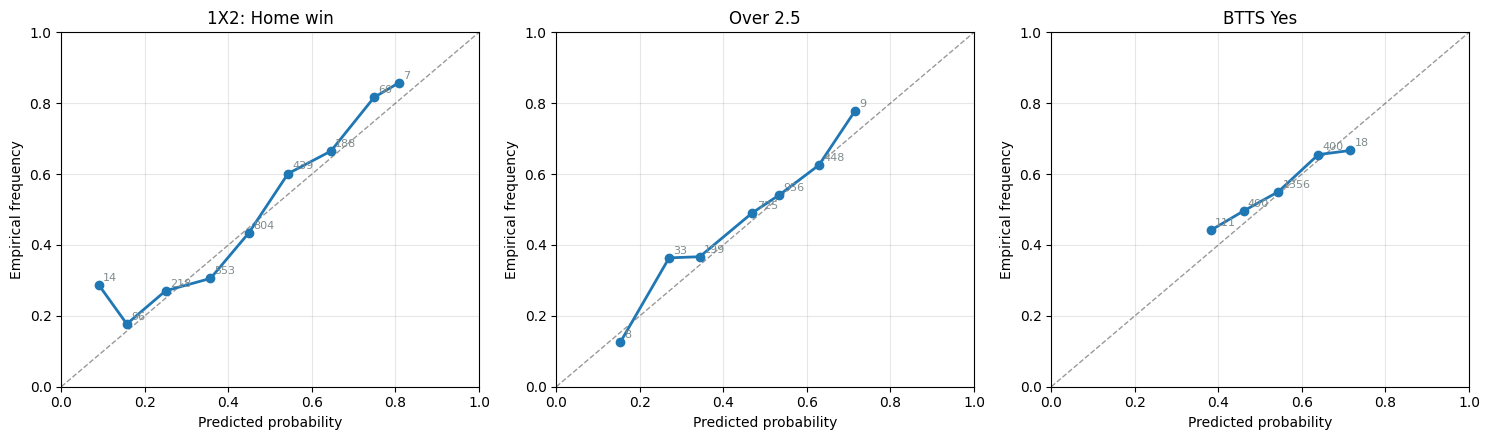

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt


def _gather_probs(market, target, pos_class='pos'):
    probs, ys = [], []
    for league in sorted(eval_data['league'].unique()):
        lt, feats = _league_slice(league, [target])
        if len(lt) < MIN_LEAGUE_ROWS:
            continue
        models = _load_ensemble(market, league)
        if not models:
            continue
        try:
            p = _ensemble_proba(models, lt[feats])
        except Exception:
            continue
        if pos_class == 'home':
            probs.append(p[:, 2])
            ys.append((lt['result_label'] == 2).astype(int).values)
        else:
            p_pos = p[:, 1] if p.shape[1] == 2 else p[:, -1]
            probs.append(p_pos)
            ys.append(lt[target].astype(int).values)
    if not probs:
        return np.array([]), np.array([])
    return np.concatenate(probs), np.concatenate(ys)


def _reliability(ax, p, y, title, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys_, counts = [], [], []
    for i in range(n_bins):
        mask = (p >= edges[i]) & (p < edges[i + 1] if i < n_bins - 1 else p <= edges[i + 1])
        if mask.sum() < 5:
            continue
        xs.append(p[mask].mean())
        ys_.append(y[mask].mean())
        counts.append(int(mask.sum()))
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1)
    ax.plot(xs, ys_, 'o-', lw=2)
    for x_, y_, c in zip(xs, ys_, counts):
        ax.annotate(str(c), (x_, y_), xytext=(3, 3),
                    textcoords='offset points', fontsize=8, color='#7f8c8d')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Empirical frequency')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
p_h, y_h = _gather_probs('1x2', 'result_label', pos_class='home')
_reliability(axes[0], p_h, y_h, '1X2: Home win')
p_o, y_o = _gather_probs('ou25', 'over_2_5')
_reliability(axes[1], p_o, y_o, 'Over 2.5')
p_b, y_b = _gather_probs('btts', 'btts')
_reliability(axes[2], p_b, y_b, 'BTTS Yes')
plt.tight_layout()
plt.show()

### Value-bet scanner

For each match in the eval window we compute `edge = model_prob * market_odds - 1`. A bet is
"flagged" when `edge >= EDGE_THRESHOLD`. ROI is computed as if we stake 1 unit on every flagged
bet: win returns `market_odds - 1`, loss returns `-1`. The processed CSV carries
`OddsH/OddsD/OddsA` (best-available bookmaker odds extracted in `data_loader.extract_odds`) and
`OddsOver25 / OddsUnder25`. Change `EDGE_THRESHOLD` or inspect per-market hit rates below.

In [11]:
EDGE_THRESHOLD = 0.05  # 5% positive edge minimum


def _value_bets_1x2():
    rows = []
    for league in sorted(eval_data['league'].unique()):
        lt, feats = _league_slice(league, ['result_label', 'OddsH', 'OddsD', 'OddsA'])
        if len(lt) < MIN_LEAGUE_ROWS:
            continue
        models = _load_ensemble('1x2', league)
        if not models:
            continue
        try:
            probs = _ensemble_proba(models, lt[feats])
        except Exception:
            continue
        # classes_: [0=A, 1=D, 2=H]
        p_a, p_d, p_h = probs[:, 0], probs[:, 1], probs[:, 2]
        odds = lt[['OddsA', 'OddsD', 'OddsH']].values
        y = lt['result_label'].astype(int).values
        for outcome_idx, (p, name, code) in enumerate([
            (p_a, 'Away', 0), (p_d, 'Draw', 1), (p_h, 'Home', 2),
        ]):
            edge = p * odds[:, outcome_idx] - 1
            mask = edge >= EDGE_THRESHOLD
            if not mask.any():
                continue
            n = int(mask.sum())
            won = (y[mask] == code)
            stake = n
            profit = float((odds[mask, outcome_idx][won] - 1).sum() - (~won).sum())
            hit = int(won.sum()) / n
            rows.append({
                'league': _display_name(league), 'market': '1X2',
                'side': name, 'n': n, 'hit': hit,
                'roi': profit / stake if stake else 0.0,
            })
    return rows


def _value_bets_ou25():
    rows = []
    for league in sorted(eval_data['league'].unique()):
        lt, feats = _league_slice(
            league, ['over_2_5', 'OddsOver25', 'OddsUnder25'])
        if len(lt) < MIN_LEAGUE_ROWS:
            continue
        models = _load_ensemble('ou25', league)
        if not models:
            continue
        try:
            probs = _ensemble_proba(models, lt[feats])
        except Exception:
            continue
        p_over = probs[:, 1]
        p_under = probs[:, 0]
        y = lt['over_2_5'].astype(int).values
        for p, side, win_val, odds_col in [
            (p_over, 'Over', 1, 'OddsOver25'),
            (p_under, 'Under', 0, 'OddsUnder25'),
        ]:
            odds = lt[odds_col].values
            edge = p * odds - 1
            mask = edge >= EDGE_THRESHOLD
            if not mask.any():
                continue
            n = int(mask.sum())
            won = (y[mask] == win_val)
            profit = float((odds[mask][won] - 1).sum() - (~won).sum())
            rows.append({
                'league': _display_name(league), 'market': 'O/U 2.5',
                'side': side, 'n': n, 'hit': int(won.sum()) / n,
                'roi': profit / n,
            })
    return rows


_rows = _value_bets_1x2() + _value_bets_ou25()
_rows.sort(key=lambda r: r['roi'], reverse=True)

if not _rows:
    display(HTML(f"<p>No flagged bets at edge &ge; {EDGE_THRESHOLD:.0%} in the "
                 f"current eval window.</p>"))
else:
    table_rows = [(r['league'], r['market'], r['side'], r['n'],
                   f"{r['hit']:.1%}", f"{r['roi']:+.1%}") for r in _rows]
    total_n = sum(r['n'] for r in _rows)
    total_hits = sum(r['hit'] * r['n'] for r in _rows)
    total_profit = sum(r['roi'] * r['n'] for r in _rows)
    pooled = (
        f'POOLED ({len(_rows)} rows)', '', '',
        total_n,
        f'{(total_hits/total_n):.1%}' if total_n else '-',
        f'{(total_profit/total_n):+.1%}' if total_n else '-',
    )
    display(HTML(
        f'<h4>Flagged value bets (edge &ge; {EDGE_THRESHOLD:.0%})</h4>' +
        _html_table(['League', 'Market', 'Side', 'N flagged', 'Hit rate', 'ROI'],
                    table_rows, pooled)))

League,Market,Side,N flagged,Hit rate,ROI
Swedish Allsvenskan,1X2,Draw,2,50.0%,+203.5%
Chinese Super League,1X2,Away,3,33.3%,+146.7%
English Championship,1X2,Draw,33,33.3%,+60.5%
English Premier League,O/U 2.5,Over,8,75.0%,+58.4%
Portuguese Liga,O/U 2.5,Under,2,50.0%,+56.5%
Danish Superliga,1X2,Draw,9,33.3%,+53.0%
Danish Superliga,1X2,Away,13,30.8%,+49.2%
English Premier League,1X2,Draw,29,31.0%,+47.8%
Portuguese Liga,1X2,Draw,58,36.2%,+43.1%
Spanish La Liga,1X2,Home,51,56.9%,+37.5%


### xG model sanity

Mean Absolute Error of the home/away xG regressors vs actual goals scored per league, pooled across
engines. Typical football-xG MAE sits around 0.90-1.05 (most games are 0-2 goals). Much higher
than that suggests a broken regressor for that league.

In [ ]:
rows_xg = []
pooled_mae_h = 0.0
pooled_mae_a = 0.0
pooled_xg_n = 0

for league in sorted(eval_data['league'].unique()):
    lt, feats = _league_slice(league, ['FTHG', 'FTAG'])
    if len(lt) < MIN_LEAGUE_ROWS:
        continue
    mh = _load_ensemble('xGH', league)
    ma = _load_ensemble('xGA', league)
    if not mh or not ma:
        continue
    try:
        hxg = _ensemble_predict(mh, lt[feats])
        axg = _ensemble_predict(ma, lt[feats])
    except Exception:
        continue
    mae_h = mean_absolute_error(lt['FTHG'].values, hxg)
    mae_a = mean_absolute_error(lt['FTAG'].values, axg)
    n = len(lt)
    rows_xg.append((_display_name(league), f'{mae_h:.3f}',
                    f'{mae_a:.3f}', f'{hxg.mean():.2f}',
                    f'{axg.mean():.2f}', n))
    pooled_mae_h += mae_h * n
    pooled_mae_a += mae_a * n
    pooled_xg_n += n

rows_xg.sort(key=lambda r: r[1])
pooled_xg = None
if pooled_xg_n:
    pooled_xg = (
        'POOLED',
        f'{pooled_mae_h/pooled_xg_n:.3f}',
        f'{pooled_mae_a/pooled_xg_n:.3f}',
        '', '', pooled_xg_n,
    )
display(HTML('<h4>xG regressor MAE (recent window)</h4>' + _html_table(
    ['League', 'MAE home', 'MAE away', 'Avg xGH', 'Avg xGA', 'N'],
    rows_xg, pooled_xg)))